## Brightness Analysis of a Distant Galaxy using Bayesian Inference

This project aims to estimate the true brightness (μ) of a celestial object and the uncertainty/noise level (σ) from noisy observations using Bayesian inference and MCMC sampling with the emcee library.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [3]:
# True values (known by nature, unknown to the model)
true_mu = 150.0
true_sigma = 10.0
n_obs = 50

# Generate noisy observations
np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

print("First 10 observations:")
print(data[:10])

First 10 observations:
[154.96714153 148.61735699 156.47688538 165.23029856 147.65846625
 147.65863043 165.79212816 157.67434729 145.30525614 155.42560044]


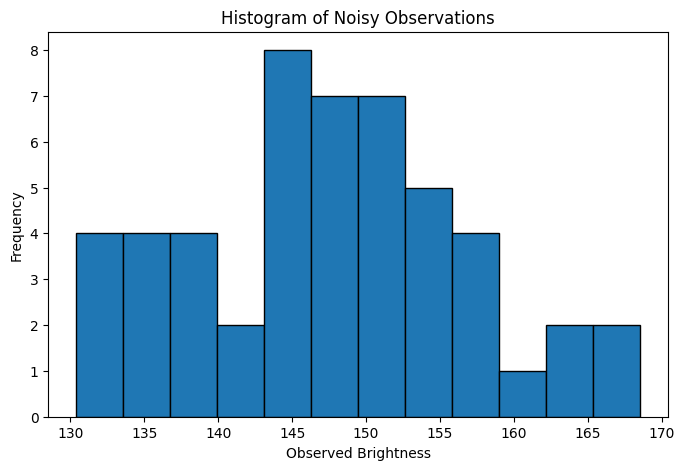

In [4]:
plt.figure(figsize=(8,5))
plt.hist(data, bins=12, edgecolor='black')
plt.xlabel("Observed Brightness")
plt.ylabel("Frequency")
plt.title("Histogram of Noisy Observations")
plt.savefig("figures/histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
def log_likelihood(theta, data):
    mu, sigma = theta
    if sigma <= 0:
        return -np.inf
    return -0.5 * np.sum(((data - mu) / sigma)**2 + np.log(2 * np.pi * sigma**2))

In [7]:
def log_prior(theta):
    mu, sigma = theta
    if 0 < mu < 300 and 0 < sigma < 50:
        return 0.0
    return -np.inf

In [8]:
def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

Why do we add?

Because in Bayes' logarithm:

logP(θ∣D) = logP(θ) + logP(D∣θ) + constant

And the constant is irrelevant during the comparison.

In [9]:
initial = [140, 5]
n_walkers = 32
n_dim = 2

pos = initial + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(data,))
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████| 2000/2000 [00:01<00:00, 1503.72it/s]


State([[146.59998341  10.42092649]
 [145.76650675  11.60857143]
 [146.31910041   9.14490759]
 [145.90858789   9.51951477]
 [149.50001792  10.6971051 ]
 [148.23997762   7.57732972]
 [145.92371546   9.17289208]
 [148.26406017  10.31640188]
 [148.47276681   9.17008242]
 [147.57449242  10.21570077]
 [150.23734833   9.44225594]
 [147.03952781   9.89079477]
 [149.14711346  11.12816338]
 [148.27233147   9.8407065 ]
 [148.62613862   9.28586118]
 [145.98667835  10.18979161]
 [145.24739774  10.44528554]
 [149.43608698   9.22811801]
 [146.40245485   8.43770594]
 [145.78330318  10.51884913]
 [147.85401389   8.45182821]
 [147.42844684   9.44192722]
 [149.10109886   8.90341593]
 [146.47069205  10.31726797]
 [147.33120777   8.41840442]
 [148.72370404   8.55018824]
 [147.63410866   8.90291161]
 [147.9781292   10.78401907]
 [148.89230751   8.80346579]
 [147.55857922  11.08242989]
 [149.9933675    9.75677827]
 [147.16186895   9.84247395]], log_prob=[-183.10672788 -185.10921796 -182.75317262 -183.1127120

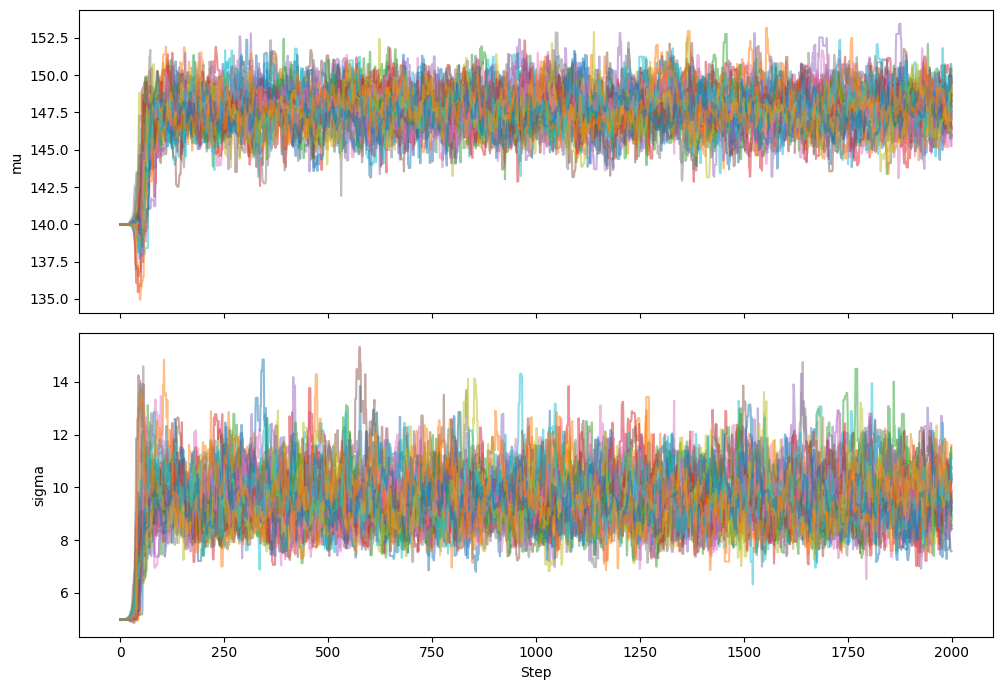

In [10]:
samples = sampler.get_chain()

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)

axes[0].plot(samples[:, :, 0], alpha=0.5)
axes[0].set_ylabel("mu")

axes[1].plot(samples[:, :, 1], alpha=0.5)
axes[1].set_ylabel("sigma")
axes[1].set_xlabel("Step")

plt.tight_layout()
plt.savefig("figures/trace_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

print("Shape of flat samples:", flat_samples.shape)

Shape of flat samples: (3200, 2)


In [12]:
mu_median = np.median(flat_samples[:, 0])
sigma_median = np.median(flat_samples[:, 1])

mu_p16, mu_p84 = np.percentile(flat_samples[:, 0], [16, 84])
sigma_p16, sigma_p84 = np.percentile(flat_samples[:, 1], [16, 84])

mu_abs_error = abs(mu_median - true_mu)
sigma_abs_error = abs(sigma_median - true_sigma)

print("mu median =", mu_median)
print("mu 16th percentile =", mu_p16)
print("mu 84th percentile =", mu_p84)
print("mu absolute error =", mu_abs_error)

print("sigma median =", sigma_median)
print("sigma 16th percentile =", sigma_p16)
print("sigma 84th percentile =", sigma_p84)
print("sigma absolute error =", sigma_abs_error)

mu median = 147.7862533013905
mu 16th percentile = 146.42607424611114
mu 84th percentile = 149.07203239392416
mu absolute error = 2.213746698609498
sigma median = 9.492117308421232
sigma 16th percentile = 8.554305529485836
sigma 84th percentile = 10.531275879457391
sigma absolute error = 0.507882691578768


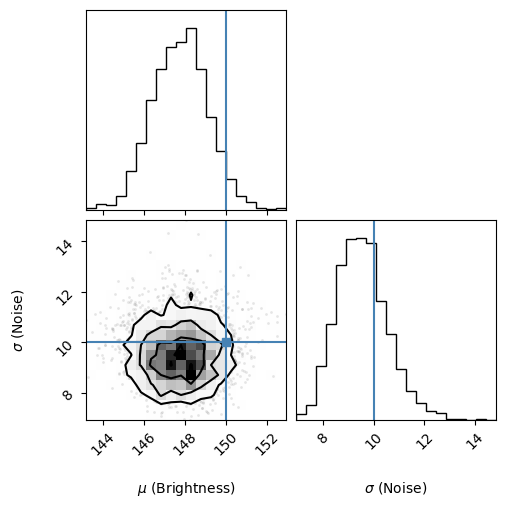

In [13]:
fig = corner.corner(
    flat_samples,
    labels=[r"$\mu$ (Brightness)", r"$\sigma$ (Noise)"],
    truths=[true_mu, true_sigma]
)
plt.savefig("figures/corner_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:

with open("results/summary.txt", "w", encoding="utf-8") as f:
    f.write("Parameter Comparison Table\n")
    f.write(f"mu     | true: {true_mu:.2f} | median: {mu_median:.2f} | p16: {mu_p16:.2f} | p84: {mu_p84:.2f} | abs error: {mu_abs_error:.2f}\n")
    f.write(f"sigma  | true: {true_sigma:.2f}  | median: {sigma_median:.2f}   | p16: {sigma_p16:.2f}   | p84: {sigma_p84:.2f}  | abs error: {sigma_abs_error:.2f}\n")